# Causal inference

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import networkx as nx
import pgmpy.base as pgmpy_base
import seaborn as sns

# Set plotting style.
# TODO(gp): Is this needed?
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
import helpers.hintrospection as hintros
import helpers.htutorial as ut
import L08_04_02_causal_inference_utils as mtl0cireout

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

Module 'networkx' is already installed.
Module 'pgmpy' is already installed.


# Part 1: Causal Roles

## Cell 1.1: Exploring causal roles in a DAG

**Goal**:
- Visualize which nodes in a DAG play the role of confounder, mediator, or
  collider relative to a selected treatment-outcome pair
- Build intuition for how graph structure determines causal relationships

**Implementation**: `mtl0cireout.cell1_causal_roles_explorer()`
- `_classify_causal_roles()` labels each node as a confounder (common
  ancestor of treatment and outcome), mediator (on a directed path from
  treatment to outcome), or collider (both path-neighbors point into it)
- `_plot_causal_roles()` colors the DAG: treatment green, outcome blue,
  confounders orange, mediators purple, colliders red, other light blue

In [3]:
hintros.print_obj_info(mtl0cireout.cell1_causal_roles_explorer)

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 38584b25ad22 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


**Usage**
- Inputs
  - **`Graph`**: select a predefined causal graph (Confounder, Mediator,
    Collider, etc.)
  - **`Treatment`**: the treatment node
  - **`Outcome`**: the outcome node
  - **`Show`**: redraw the DAG for the current selection

- Panels
  - the DAG, color-coded by causal role, with a legend naming the
    confounders/mediators/colliders for the current treatment-outcome
    pair

In [5]:
mtl0cireout.cell1_causal_roles_explorer()

**Guided usage**
- Select the `Collider` graph, with `Treatment=X`, `Outcome=Y`
  - Observe `C` is colored red: it is a collider, since both `X` and `Y`
    point into it
- Switch to the `Confounder + Mediator` graph
  - Observe `Z` is orange (confounder of `X`, `Y`) and `M` is purple
    (mediator on the `X`-`Y` path): the same graph position can carry
    different roles depending on the treatment-outcome pair chosen

# Part 2: D-Separation Basics

## Cell 2.1: Building and visualizing a DAG

**Goal**:
- Build a specific DAG to use as a running example for querying
  d-separation properties by hand

**Implementation**: `mtl0cireout.plot_graph_highlight(model)`

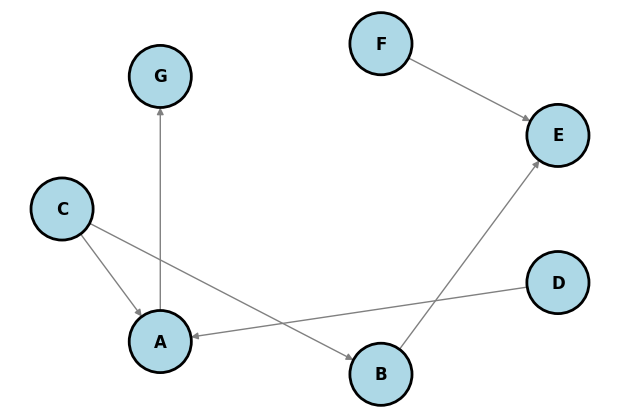

In [6]:
model = nx.DiGraph(
    [
        ("C", "A"),
        ("C", "B"),
        ("D", "A"),
        ("B", "E"),
        ("F", "E"),
        ("A", "G"),
    ]
)

mtl0cireout.plot_graph_highlight(model)

## Cell 2.2: Querying d-separation with pgmpy

**Goal**:
- Demonstrate how conditioning on a node can open or close paths between
  2 other nodes, by querying `pgmpy`'s exact d-separation check

**Implementation**: `dag.is_dconnected(node1, node2, observed=...)`
- `D` and `C` are connected only through the collider `D -> A <- G`:
  unobserved, the collider blocks the path; observing `A`, or its
  descendant `G`, opens it
- `G` and `D` are connected only through the chain `D -> A -> G`: open
  when `A` is unobserved, blocked once `A` is observed
- `G` and `F` are connected only through the path `G-A-C-B-E-F`, which
  needs the collider `E` to be observed (and `A`, `C`, `B` to stay
  unobserved) to become active

In [7]:
# Convert the NetworkX graph to a pgmpy DAG.
dag = pgmpy_base.DAG(model.edges())

Are D and C dependent?
True


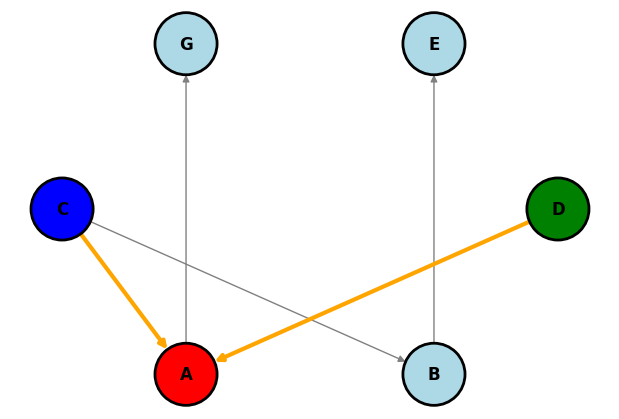

In [8]:
# `dag.is_dconnected()` already returns True when the 2 nodes are
# d-connected (dependent), so it is read directly, with no negation.
print("D, C dependent (unconditional):", dag.is_dconnected("D", "C"))
print("D, C dependent (given A):", dag.is_dconnected("D", "C", observed={"A"}))
print("D, C dependent (given G):", dag.is_dconnected("D", "C", observed={"G"}))
print("G, D dependent (unconditional):", dag.is_dconnected("G", "D"))
print("G, D dependent (given A):", dag.is_dconnected("G", "D", observed=["A"]))
print("G, F dependent (unconditional):", dag.is_dconnected("G", "F"))
print("G, F dependent (given E):", dag.is_dconnected("G", "F", observed=["E"]))

# Part 3: Interactive D-Separation Explorer

## Cell 3.1: Exploring d-separation interactively

**Goal**:
- Interactively explore d-separation for any pair of nodes in the DAG
  built in Part 2
- See how adding nodes to the conditioning set opens or closes paths

**Implementation**: `mtl0cireout.cell3_d_separation_explorer(model, dag)`
- Plots the reachable subgraph containing the selected nodes and their
  descendants, then reports `dag.is_dconnected()` for the current
  selection

In [9]:
hintros.print_obj_info(mtl0cireout.cell3_d_separation_explorer)

Are D and C dependent given A?
False


**Usage**
- Inputs
  - **`Node 1`**: first node to query
  - **`Node 2`**: second node to query
  - **`Conditioning`**: set of nodes to condition on (shift-click to
    select multiple)
  - **`Run`**: recompute the plot and the d-separation result

- Panels
  - the reachable subgraph, with node1 green, node2 blue, conditioning
    nodes red, and paths between node1 and node2 highlighted in orange
  - a printed line reporting whether node1/node2 are dependent given the
    current conditioning set

In [15]:
mtl0cireout.cell3_d_separation_explorer(
    model,
    dag,
)

**Guided usage**
- Set `Node 1=D`, `Node 2=C`, with no conditioning
  - Observe they are reported as not dependent: the path is blocked at
    the unobserved collider `A`
- Add `A` to `Conditioning`
  - Observe they become dependent: conditioning on a collider between 2
    nodes opens a previously closed path
- Set `Node 1=G`, `Node 2=D`, with `A` in `Conditioning`
  - Observe they become independent: conditioning on the mediator `A`
    blocks the causal path from `D` to `G`